## 4.1 Baseline XGBoost Model

**Business Question:** Can we build a model that reliably identifies which customers
are likely to churn — and how well does it perform on unseen data?

A baseline model gives us a reference point. We train XGBoost with default settings
first — no tuning, no tricks. This tells us what the data can do on its own, before
we optimize anything. Every improvement in later steps is measured against this baseline.

In [2]:
from  google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Create the directory if it doesn't exist
output_dir = 'visuals'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory '{output_dir}' created.")
else:
    print(f"Directory '{output_dir}' already exists.")

Train shape: (5634, 34)
Test shape:  (1409, 34)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:12:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



ROC-AUC Score: 0.8226

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.86      1035
       Churn       0.60      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



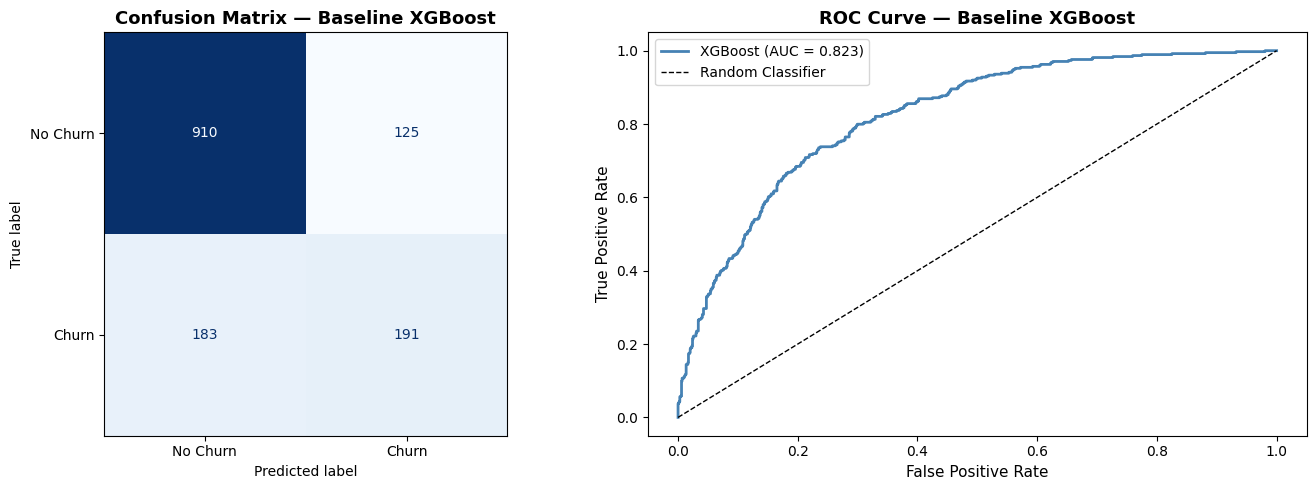

Plot saved.


In [6]:
# ── 4.1 Baseline XGBoost Model ──────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── 1. Load processed data ───────────────────────────────────────────────────
X_train = pd.read_csv("/content/drive/MyDrive/projects /customer churn analysis/Data/processed/X_train.csv")
X_test  = pd.read_csv("/content/drive/MyDrive/projects /customer churn analysis/Data/processed/X_test.csv")
y_train = pd.read_csv("/content/drive/MyDrive/projects /customer churn analysis/Data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("/content/drive/MyDrive/projects /customer churn analysis/Data/processed/y_test.csv").squeeze()

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

# ── 2. Train baseline model ──────────────────────────────────────────────────
baseline_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

baseline_model.fit(X_train, y_train)

# ── 3. Predictions ───────────────────────────────────────────────────────────
y_pred      = baseline_model.predict(X_test)
y_pred_prob = baseline_model.predict_proba(X_test)[:, 1]

# ── 4. Core metrics ──────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# ── 5. Confusion Matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Baseline XGBoost", fontsize=13, fontweight="bold")

# ── 6. ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("ROC Curve — Baseline XGBoost", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projects /customer churn analysis/visuals/04_baseline_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

### Findings — 4.1 Baseline Model

- **ROC-AUC: 0.8226** — strong discrimination ability on default settings.
  The model separates churners from non-churners 82% of the time, well above
  the 50% random baseline.

- **Churn Recall: 0.51** — the model correctly identifies only 51% of actual
  churners. 183 out of 374 churners were missed entirely (false negatives).
  In a business context, these are customers who would leave undetected —
  no intervention, no retention offer.

- **Churn Precision: 0.60** — when the model flags a customer as likely to
  churn, it is correct 60% of the time. The other 40% are false alarms
  (125 customers flagged unnecessarily).

- Overall accuracy (78%) is misleading on this imbalanced dataset. The model
  is conservative — it over-predicts "No Churn" because that is the majority class.

- **Primary goal for Step 4.2:** improve churn recall specifically, accepting
  that some increase in false positives is a reasonable trade-off. Missing a
  churner costs more than a wasted retention call.